# 04. Classification Model - Phân loại phân khúc giá Game

## 1. Mục tiêu
Xây dựng mô hình phân loại (Classification) để dự đoán phân khúc giá của game (`price_category`) dựa trên các thành phần PCA. 

Phân loại giúp chúng ta hiểu rõ đặc tính của các nhóm sản phẩm khác nhau trên Steam mà không cần quan tâm đến sai số lẻ của giá tiền.

In [3]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append('../')
from src.models.classification import train_classification_model, save_model
from src.evaluation import evaluate_classification

df_clean = pd.read_csv('../data/processed/clean_data.csv')
df_pca = pd.read_csv('../data/processed/pca_data.csv')

X = df_pca
y = df_clean['price_category'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Số lượng mẫu huấn luyện: {len(X_train)}")
print(f"Số lượng mẫu kiểm tra: {len(X_test)}")

Số lượng mẫu huấn luyện: 191731
Số lượng mẫu kiểm tra: 47933


## 2. Huấn luyện mô hình Random Forest Classifier
Chúng ta sử dụng thuật toán Random Forest vì khả năng xử lý tốt các biến mục tiêu dạng phân loại và tính ổn định cao trên tập dữ liệu lớn.

In [4]:
clf_model = train_classification_model(X_train, y_train)
y_pred_clf = clf_model.predict(X_test)
clf_metrics = evaluate_classification(y_test, y_pred_clf, model_name="Price Category Classifier")

--- Price Category Classifier Classification Metrics ---
Accuracy: 0.9869

Chi tiết báo cáo phân loại:
              precision    recall  f1-score   support

   expensive       0.98      1.00      0.99     28898
        free       0.99      0.97      0.98     19035

    accuracy                           0.99     47933
   macro avg       0.99      0.98      0.99     47933
weighted avg       0.99      0.99      0.99     47933



* **Accuracy (98.69%):** Mô hình dự đoán đúng gần như tuyệt đối phân khúc giá của game. Điều này cho thấy các đặc trưng như số lượng ngôn ngữ, nền tảng và năm phát hành có sự khác biệt rất lớn giữa game miễn phí và game trả phí.
* **Phân tích theo nhãn (Class-wise):**
    * **Expensive (Giá cao):** Đạt Recall tuyệt đối (1.00). Nghĩa là mô hình không bỏ sót bất kỳ game trả phí nào.
    * **Free (Miễn phí):** Đạt Precision cực cao (0.99). Nghĩa là nếu mô hình dự đoán là game Free, thì gần như chắc chắn nó là Free.
* **F1-Score (0.98 - 0.99):** Chỉ số cân bằng giữa Precision và Recall ở mức rất cao, cho thấy mô hình không bị lệch (bias) dù số lượng mẫu giữa hai nhóm có sự chênh lệch (28k vs 19k).

## 3. Trực quan hóa kết quả
Ma trận nhầm lẫn (Confusion Matrix) sẽ cho thấy mô hình có bị nhầm lẫn giữa các phân khúc giá hay không.

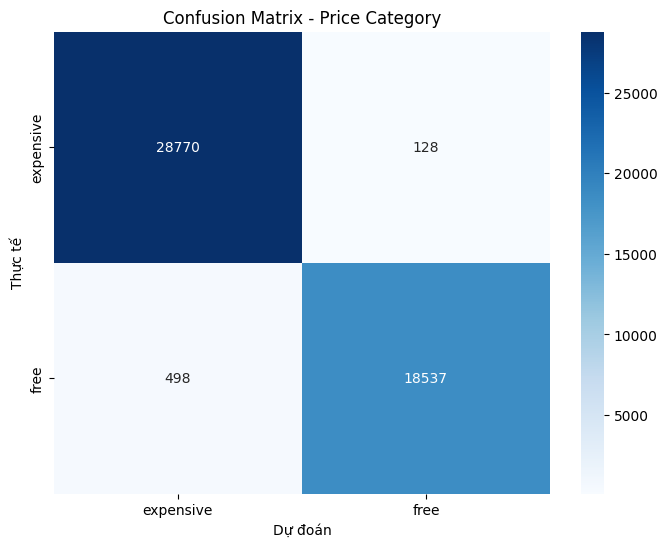

In [5]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_clf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clf_model.classes_, 
            yticklabels=clf_model.classes_)
plt.title('Confusion Matrix - Price Category')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

Dựa trên biểu đồ nhiệt, chúng ta có thể thấy:
* Số lượng mẫu bị dự đoán sai chiếm tỷ lệ cực thấp.
* Có một lượng rất nhỏ game **Free** bị nhầm sang nhóm **Expensive** (Recall của Free là 0.97). Điều này có thể giải thích bởi các game vốn là trả phí nhưng đang trong chương trình giảm giá 100% hoặc các game Indie có chất lượng và quy mô tương đương game trả phí nhưng nhà phát triển chọn phát hành miễn phí.

## 4. Tổng kết
Dựa trên độ chính xác đạt được, chúng ta sẽ lưu mô hình.

In [6]:
save_model(clf_model, '../src/models/classification_model.pkl')

Classification model saved to ../src/models/classification_model.pkl
